In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Data Loading

In [3]:
mtir = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
di = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
bt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
cPb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
cPt = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
bv = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
bb = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
sample = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
sample.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

In [5]:
dataframes = {
    'movie_theater_id_relation' : mtir,
    'date_info' : di,
    'booknow_theaters' : bt,
    'cinePOS_booking' : cPb,
    'cinePOS_theaters' : cPt,
    'booknow_visits' : bv,
    'booknow_booking.' : bb,
    'sample_submission' : sample
}


    
for name , df in dataframes.items():
    print(f"\n--- {name} ---")
    print(f"Shape : {df.shape}")
    print("Columns :", df.columns.tolist())
    print("Info :\n", df.info())
    print("Sample data :\n", df.head())
    print("Duplicate rows : ",df.duplicated().sum())
    print("Null values count : ", df.isna().sum())


--- movie_theater_id_relation ---
Shape : (150, 2)
Columns : ['book_theater_id', 'cine_theater_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB
Info :
 None
Sample data :
   book_theater_id cine_theater_id
0      book_00509   cinePOS_01261
1      book_00063   cinePOS_02467
2      book_00054   cinePOS_08923
3      book_00094   cinePOS_02479
4      book_00052   cinePOS_06750
Duplicate rows :  0
Null values count :  book_theater_id    0
cine_theater_id    0
dtype: int64

--- date_info ---
Shape : (547, 2)
Columns : ['show_date', 'day_of_week']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       ---------

## EDA on Booknow Visits dataset

In [5]:
bv_copy = bv.copy()

In [6]:
bv_copy['book_theater_id'].nunique()

826

In [7]:
bv_copy.duplicated().sum()

10

In [8]:
bv_copy.drop_duplicates(inplace=True)

In [9]:
bv_copy.duplicated().sum()

0

In [10]:
bv_copy["show_date"] = pd.to_datetime(bv_copy["show_date"])
print("First date: ", bv_copy['show_date'].min())
print("Last date: ", bv_copy['show_date'].max())


First date:  2023-01-01 00:00:00
Last date:  2024-02-28 00:00:00


In [11]:
bv_copy.describe()

,show_date,audience_count
count,214036,214036.000000
mean,2023-09-13 04:20:40.210058240,41.617728
min,2023-01-01 00:00:00,2.000000
25%,2023-07-09 00:00:00,18.000000
50%,2023-09-25 00:00:00,34.000000
75%,2023-12-11 00:00:00,58.000000
max,2024-02-28 00:00:00,1350.000000
std,NaN,32.835180


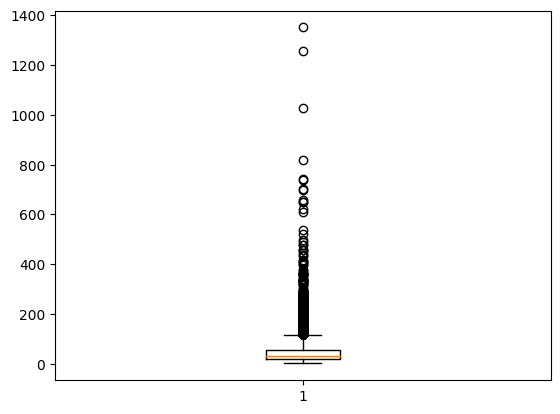

In [12]:
plt.boxplot(bv_copy["audience_count"])
plt.show()

In [13]:
q1 = bv_copy["audience_count"].quantile(0.25)
q3 = bv_copy["audience_count"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = bv_copy[(bv_copy["audience_count"] < lower_bound) | (bv_copy["audience_count"] > upper_bound)]
print(outliers)

       book_theater_id  show_date  audience_count
140         book_00001 2023-07-01             122
639         book_00003 2023-07-10             132
1315        book_00005 2023-09-18             122
1404        book_00005 2023-12-16             120
1418        book_00005 2023-12-30             134
...                ...        ...             ...
212718      book_00825 2023-11-19             134
212734      book_00825 2023-12-05             128
212737      book_00825 2023-12-08             128
212752      book_00825 2023-12-23             140
212781      book_00825 2024-01-22             122

[5589 rows x 3 columns]


In [14]:
bv_copy = bv_copy.sort_values('show_date').set_index("show_date")
bv_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 214036 entries, 2023-01-01 to 2024-02-28
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214036 non-null  object
 1   audience_count   214036 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.9+ MB


In [15]:
bv_copy.head()

,book_theater_id,audience_count
show_date,,
2023-01-01,book_00140,22
2023-01-01,book_00128,124
2023-01-01,book_00754,32
2023-01-01,book_00494,62
2023-01-01,book_00703,204


<Axes: xlabel='show_date'>

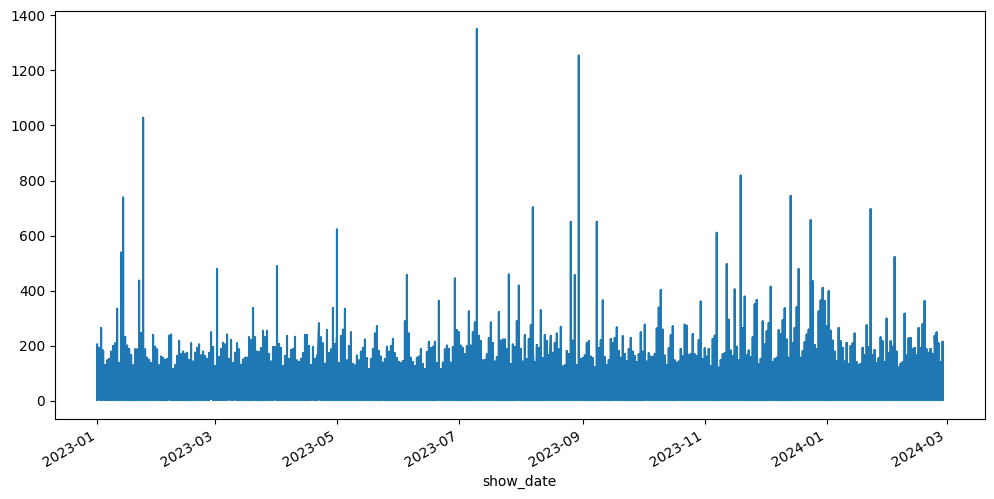

In [16]:
bv_copy['audience_count'].plot(figsize=(12,6))

<Axes: xlabel='show_date'>

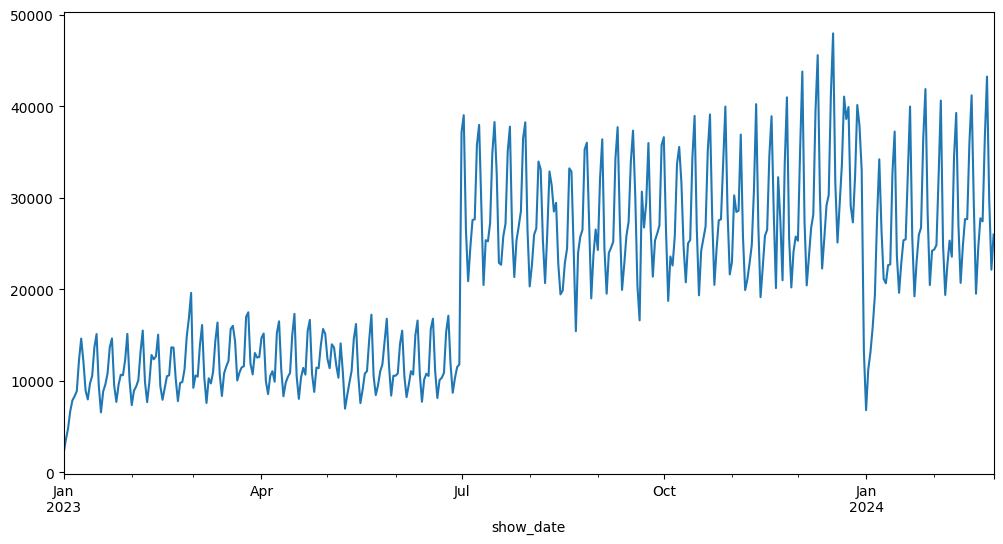

In [17]:
daily_bv = bv_copy["audience_count"].resample("D").sum()
daily_bv.plot(figsize=(12,6))

In [18]:
daily_bv

show_date
2023-01-01     2066
2023-01-02     3528
2023-01-03     4736
2023-01-04     6652
2023-01-05     7854
              ...  
2024-02-24    36466
2024-02-25    43246
2024-02-26    29856
2024-02-27    22142
2024-02-28    25980
Freq: D, Name: audience_count, Length: 424, dtype: int64

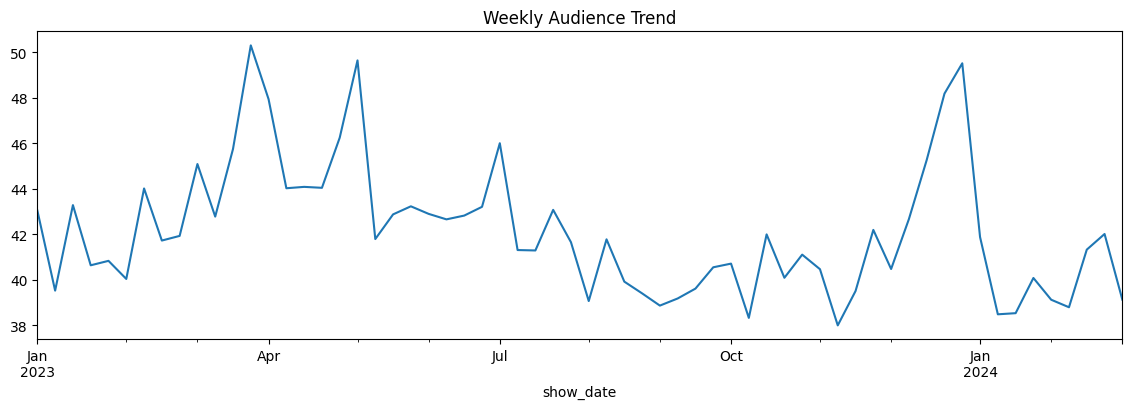

In [19]:
weekly_bv = bv_copy["audience_count"].resample("W").mean()
weekly_bv.plot(figsize=(14,4), title="Weekly Audience Trend")
plt.show()

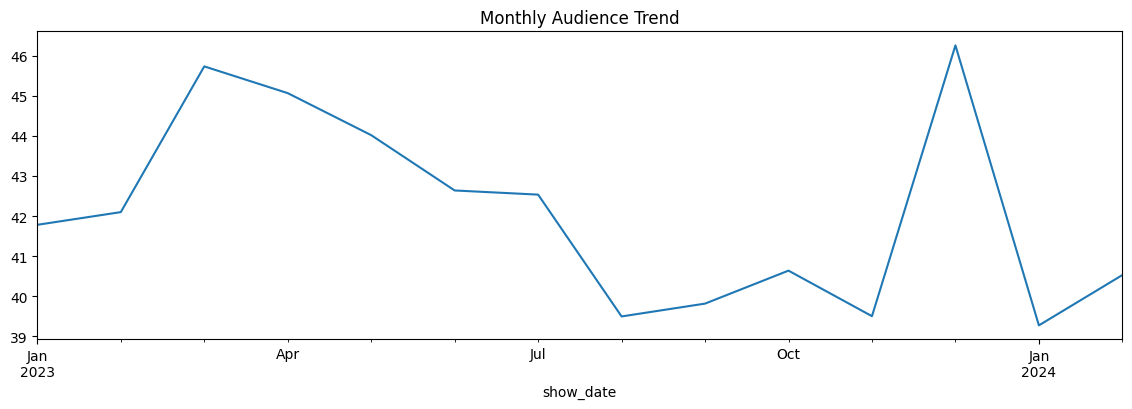

In [20]:
monthly_bv = bv_copy["audience_count"].resample("ME").mean()
monthly_bv.plot(figsize=(14,4), title="Monthly Audience Trend")
plt.show()

<Axes: xlabel='show_date'>

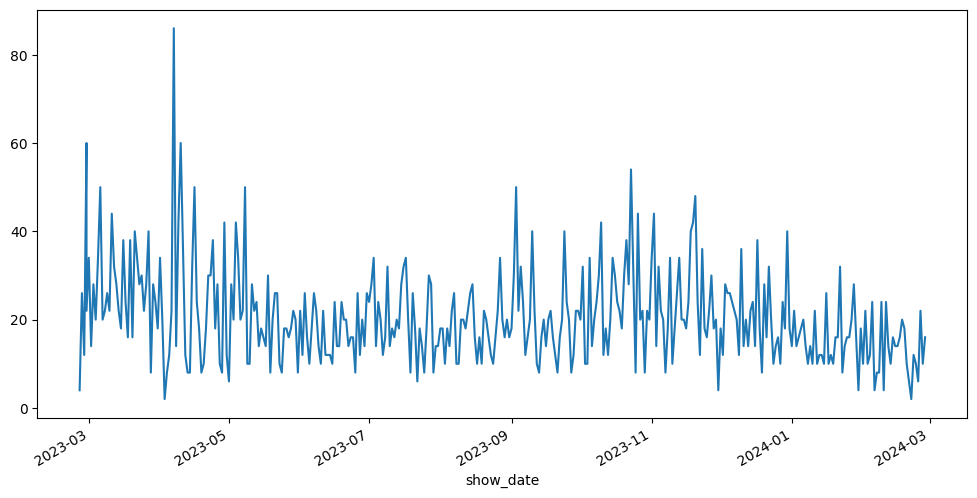

In [21]:
one_bv = bv_copy[bv_copy.book_theater_id == "book_00004"]
one_bv["audience_count"].plot(figsize=(12,6))


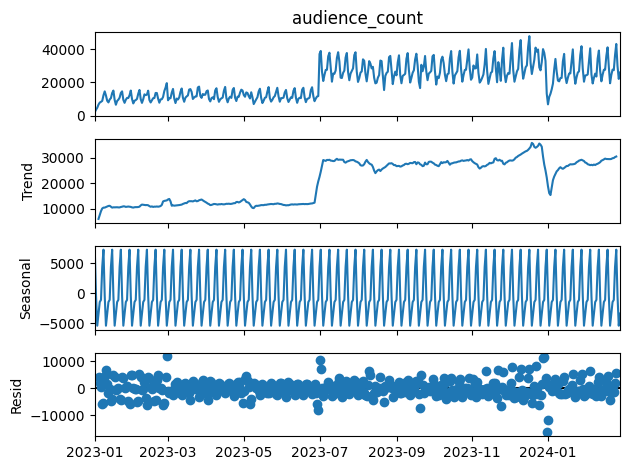

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(daily_bv, model="additive", period=7)  
result.plot()
plt.show()

## Time Series Decomposition Analysis

### Graph Overview
This visualization displays an additive seasonal decomposition of audience count data from January 2023 to January 2024.

### Components Breakdown

### **Top Panel: Observed Data (audience_count)**
- Shows the original time series data
- Values range from approximately 0 to 40,000
- Displays both trend and seasonal patterns throughout the year

### **Second Panel: Trend Component**
- Reveals the underlying long-term pattern
- Values range between approximately 10,000 and 30,000
- Shows the overall direction and movement of audience counts

### **Third Panel: Seasonal Component**
- Displays regular, repeating patterns
- Values oscillate between approximately -5,000 and +5,000
- Shows consistent seasonal fluctuations around zero

### **Bottom Panel: Residual Component**
- Represents random noise and irregular fluctuations
- Values range between approximately -10,000 and +10,000
- Shows what remains after removing trend and seasonal components

### Key Characteristics
- **Model Type**: Additive decomposition
- **Pattern**: Clear seasonal patterns with identifiable trend component
- **Scale**: Significant fluctuations in both seasonal and residual components

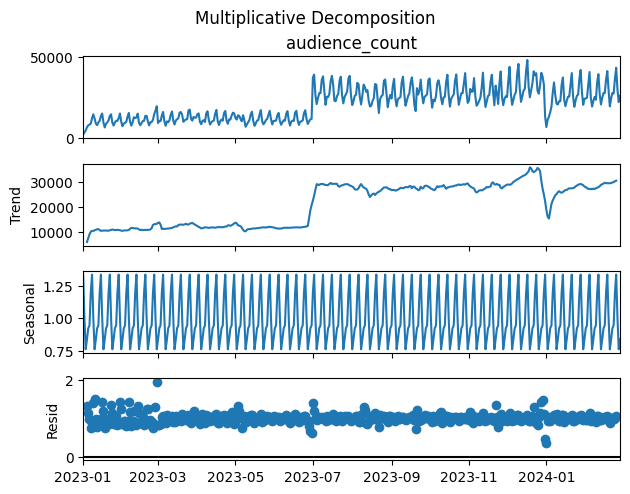

In [23]:
result_multi = seasonal_decompose(daily_bv, model="multiplicative", period=7)
result_multi.plot()
plt.suptitle('Multiplicative Decomposition', y=1.02)
plt.show()

## Multiplicative Decomposition Analysis

### Graph Overview
This visualization displays a multiplicative seasonal decomposition of audience count data from January 2023 to January 2024.

### Components Breakdown

### **Top Panel: Observed Data**
- Shows the original time series data for audience count
- Values range from approximately 0 to 50,000
- Displays clear seasonal patterns and overall trend

### **Second Panel: Trend Component**
- Reveals the underlying long-term pattern
- Shows fluctuations in the overall trend over the one-year period
- Values range between approximately 10,000 and 30,000

### **Third Panel: Seasonal Component**
- Displays repeating weekly patterns (period=7)
- Shows consistent seasonal fluctuations around 1.0
- Values oscillate between approximately 0.75 and 1.25
- Demonstrates regular weekly audience behavior patterns

### **Bottom Panel: Residual Component**
- Represents the random noise or irregular fluctuations
- Shows what remains after removing trend and seasonal components
- Values cluster around 0 with some outliers

### Key Insights
- **Seasonal Period**: 7 days (weekly patterns)
- **Model Type**: Multiplicative decomposition
- **Pattern**: Clear weekly seasonality with evolving trend

In [24]:
one_bv.head()

,book_theater_id,audience_count
show_date,,
2023-02-25,book_00004,4
2023-02-26,book_00004,26
2023-02-27,book_00004,12
2023-02-28,book_00004,60
2023-02-28,book_00004,22


In [25]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [26]:
adf_test(bv_copy["audience_count"])

ADF Statistics: -22.621398663916846
p- value: 0.0
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


**The time series data is stationary and suitable for time series modeling**

## EDA on cinePOS_booking dataset

In [27]:
cPb_copy = cPb.copy()

In [28]:
cPb_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB


In [29]:
cPb_copy['show_datetime'] = pd.to_datetime(cPb_copy['show_datetime'])
cPb_copy['booking_datetime'] = pd.to_datetime(cPb_copy['booking_datetime'])
cPb_copy['show_date'] = cPb_copy['show_datetime'].dt.date
cPb_copy['show_date'] = pd.to_datetime(cPb_copy['show_date'])
cPb_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   cine_theater_id   1641966 non-null  object        
 1   show_datetime     1641966 non-null  datetime64[ns]
 2   booking_datetime  1641966 non-null  datetime64[ns]
 3   tickets_sold      1641966 non-null  int64         
 4   show_date         1641966 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 62.6+ MB


In [30]:
print(cPb_copy['cine_theater_id'].nunique())
print(cPb_copy['tickets_sold'].describe())

13161
count    1.641966e+06
mean     4.987345e+00
std      5.234901e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      1.000000e+02
Name: tickets_sold, dtype: float64


In [31]:
print("Start date: ", cPb_copy['show_date'].min())
print("Last date: ", cPb_copy['show_date'].max())

Start date:  2023-01-01 00:00:00
Last date:  2024-02-28 00:00:00


In [32]:
cPb_copy = cPb_copy.sort_values('show_date').set_index('show_date')
cPb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB


In [33]:
cPb_copy.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
show_date,,,,
2023-01-01,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
2023-01-01,cinePOS_00087,2023-01-01 19:00:00,2023-01-01 10:00:00,2
2023-01-01,cinePOS_00052,2023-01-01 19:00:00,2023-01-01 18:00:00,2
2023-01-01,cinePOS_00054,2023-01-01 19:00:00,2023-01-01 15:00:00,5
2023-01-01,cinePOS_00088,2023-01-01 19:00:00,2023-01-01 10:00:00,2


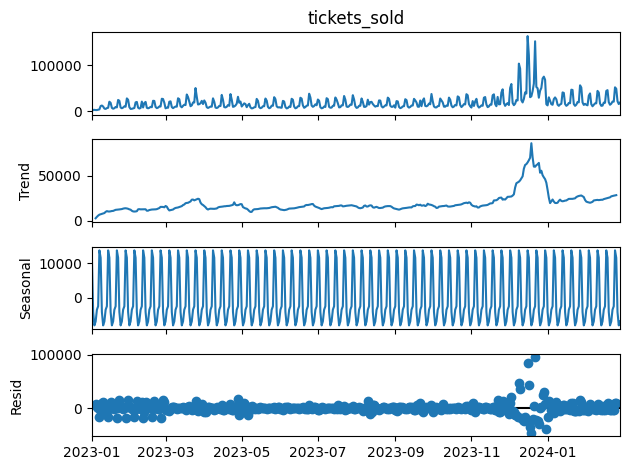

In [34]:
daily_cPb = cPb_copy['tickets_sold'].resample('D').sum()
result = seasonal_decompose(daily_cPb, model="additive", period=7)  # weekly seasonality
result.plot()
plt.show()

## EDA on booknow_booking datasets

In [35]:
bb_copy = bb.copy()

In [36]:
bb_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [37]:
bb_copy['show_datetime'] = pd.to_datetime(bb_copy['show_datetime'])
bb_copy['booking_datetime'] = pd.to_datetime(bb_copy['booking_datetime'])
bb_copy['show_date'] = bb_copy['show_datetime'].dt.date
bb_copy['show_date'] = pd.to_datetime(bb_copy['show_date'])
bb_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   book_theater_id   68336 non-null  object        
 1   show_datetime     68336 non-null  datetime64[ns]
 2   booking_datetime  68336 non-null  datetime64[ns]
 3   tickets_booked    68336 non-null  int64         
 4   show_date         68336 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(1)
memory usage: 2.6+ MB


In [38]:
print(bb_copy['book_theater_id'].nunique())
bb_copy['tickets_booked'].describe()

301


count    68336.000000
mean         4.425808
std          4.808945
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        100.000000
Name: tickets_booked, dtype: float64

In [39]:
print("start date: ", bb_copy['show_date'].min())
print("last date: ", bb_copy['show_date'].max())

start date:  2023-01-01 00:00:00
last date:  2024-02-28 00:00:00


In [40]:
bb_copy = bb_copy.sort_values("show_date").set_index("show_date")
bb_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68336 entries, 2023-01-01 to 2024-02-28
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   book_theater_id   68336 non-null  object        
 1   show_datetime     68336 non-null  datetime64[ns]
 2   booking_datetime  68336 non-null  datetime64[ns]
 3   tickets_booked    68336 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 2.6+ MB


In [41]:
bb_copy.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
show_date,,,,
2023-01-01,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
2023-01-01,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2023-01-01,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
2023-01-01,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
2023-01-01,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


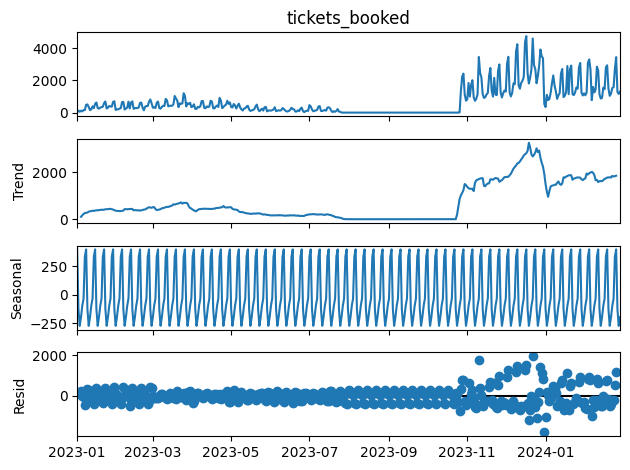

In [42]:
daily_bb = bb_copy['tickets_booked'].resample("D").sum()
result_bb = seasonal_decompose(daily_bb, model='additive', period=7)
result_bb.plot()
plt.show()

## EDA on sample submission dataset

In [43]:
sample_copy = sample.copy()

In [44]:
print(sample_copy.head())
print(sample_copy.tail())
print(sample_copy.info())

                      ID  audience_count
0  book_00001_2024-03-01               0
1  book_00001_2024-03-02               0
2  book_00001_2024-03-03               0
3  book_00001_2024-03-04               0
4  book_00001_2024-03-06               0
                          ID  audience_count
38057  book_00829_2024-04-18               0
38058  book_00829_2024-04-19               0
38059  book_00829_2024-04-20               0
38060  book_00829_2024-04-21               0
38061  book_00829_2024-04-22               0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              38062 non-null  object
 1   audience_count  38062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 594.8+ KB
None


In [45]:
sample_copy["book_id"] = sample_copy["ID"].str.split("_").str[:2].str.join("_")
sample_copy.head()

,ID,audience_count,book_id
0,book_00001_2024-03-01,0,book_00001
1,book_00001_2024-03-02,0,book_00001
2,book_00001_2024-03-03,0,book_00001
3,book_00001_2024-03-04,0,book_00001
4,book_00001_2024-03-06,0,book_00001


In [46]:
sample_copy.tail()

,ID,audience_count,book_id
38057,book_00829_2024-04-18,0,book_00829
38058,book_00829_2024-04-19,0,book_00829
38059,book_00829_2024-04-20,0,book_00829
38060,book_00829_2024-04-21,0,book_00829
38061,book_00829_2024-04-22,0,book_00829


In [47]:
sample_copy['book_id'].nunique()

827

**Key Insight from EDA**

**What I Had**
- Data from January 2023 to February 2024
- Needed to predict from March to April 2024

**What I Found**
- The data showed clear weekly patterns - audience numbers follow a 7-day cycle.

# Baseline Model

## 1 SARIMA

In [48]:
print(bv.info())
print(bv.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB
None
  book_theater_id   show_date  audience_count
0      book_00001  2023-01-13              50
1      book_00001  2023-01-14              64
2      book_00001  2023-01-15              58
3      book_00001  2023-01-16              44
4      book_00001  2023-01-18              12


In [49]:
bv["show_date"] = pd.to_datetime(bv["show_date"])
bv = bv.sort_values(["book_theater_id", "show_date"])
bv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB


In [50]:
def get_ts(theater_id):
    df = bv[bv['book_theater_id'] == theater_id][['show_date','audience_count']]
    df['show_date'] = pd.to_datetime(df['show_date'])
    df = df.groupby('show_date')['audience_count'].sum().to_frame()
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
    df = df.reindex(full_idx)
    df.index.name = 'show_date'
    df['audience_count'] = df['audience_count'].fillna(0)
    return df


**Creates a continuous daily time series suitable for time series analysis, ensuring no gaps in the date sequence and handling missing show days appropriately.**

In [51]:
theater = bv['book_theater_id'].value_counts().idxmax()
ts = get_ts(theater)
ts.head()

,audience_count
show_date,
2023-01-02,48
2023-01-03,98
2023-01-04,20
2023-01-05,4
2023-01-06,18


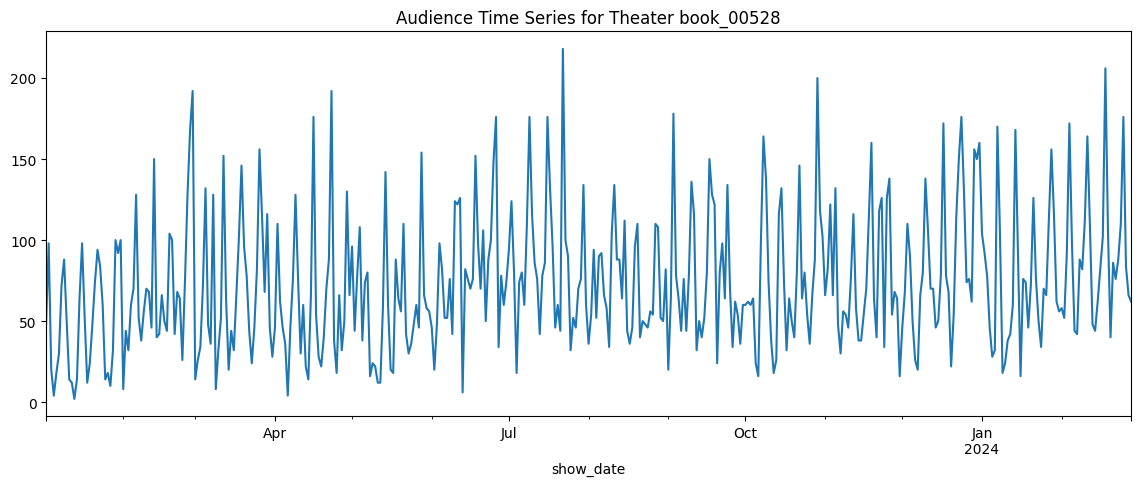

In [52]:
ts['audience_count'].plot(figsize=(14,5), title=f"Audience Time Series for Theater {theater}")
plt.show()


In [53]:
train = ts.iloc[:-30]
test  = ts.iloc[-30:]


In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['audience_count'],
    order=(1,1,1),
    seasonal_order=(2,1,2,7)
)

res = model.fit()

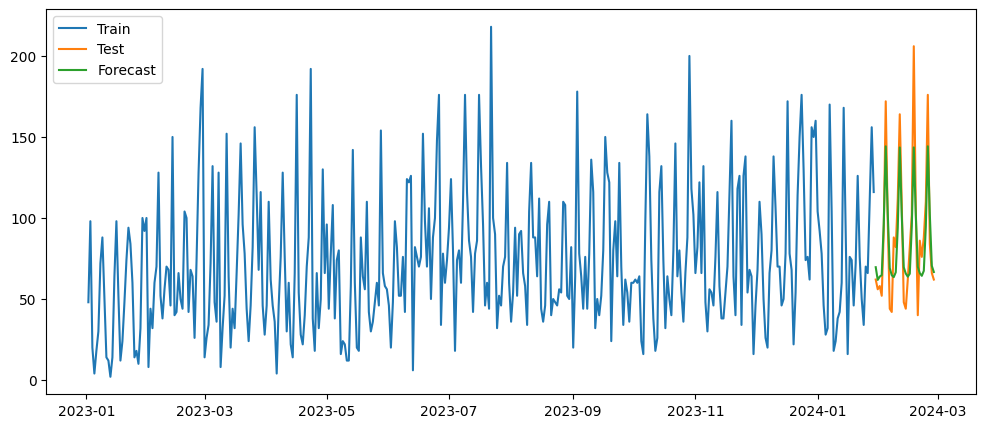

In [55]:
pred = res.get_forecast(steps=30)
forecast = pred.predicted_mean

plt.figure(figsize=(12,5))
plt.plot(train.index, train['audience_count'], label='Train')
plt.plot(test.index, test['audience_count'], label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

In [56]:

sample["book_theater_id"] = sample["ID"].str.split("_").str[:2].str.join("_")
sample["show_date"] = pd.to_datetime(sample["ID"].str.split("_").str[2])

In [57]:
bv_agg = bv.groupby(["book_theater_id", "show_date"])["audience_count"].sum().reset_index()

In [58]:
full_dates = pd.date_range(bv_agg["show_date"].min(), bv_agg["show_date"].max())


def get_ts(theater_id):
    ts = bv_agg[bv_agg["book_theater_id"]==theater_id][["show_date","audience_count"]].set_index("show_date")
    ts = ts.reindex(full_dates, fill_value=0)
    return ts

In [59]:
# full_dates

In [60]:
sample

,ID,audience_count,book_theater_id,show_date
0,book_00001_2024-03-01,0,book_00001,2024-03-01
1,book_00001_2024-03-02,0,book_00001,2024-03-02
2,book_00001_2024-03-03,0,book_00001,2024-03-03
3,book_00001_2024-03-04,0,book_00001,2024-03-04
4,book_00001_2024-03-06,0,book_00001,2024-03-06
...,...,...,...,...
38057,book_00829_2024-04-18,0,book_00829,2024-04-18
38058,book_00829_2024-04-19,0,book_00829,2024-04-19
38059,book_00829_2024-04-20,0,book_00829,2024-04-20
38060,book_00829_2024-04-21,0,book_00829,2024-04-21


In [61]:
len(bv_agg["book_theater_id"].unique())
sample[sample["book_theater_id"]=="book_00001"]["show_date"]

0    2024-03-01
1    2024-03-02
2    2024-03-03
3    2024-03-04
4    2024-03-06
5    2024-03-07
6    2024-03-08
7    2024-03-09
8    2024-03-10
9    2024-03-11
10   2024-03-12
11   2024-03-13
12   2024-03-14
13   2024-03-15
14   2024-03-16
15   2024-03-17
16   2024-03-18
17   2024-03-19
18   2024-03-21
19   2024-03-22
20   2024-03-23
21   2024-03-24
22   2024-03-25
23   2024-03-27
24   2024-03-28
25   2024-03-29
26   2024-03-30
27   2024-03-31
28   2024-04-01
29   2024-04-02
30   2024-04-03
31   2024-04-04
32   2024-04-05
33   2024-04-06
34   2024-04-07
35   2024-04-08
36   2024-04-10
37   2024-04-11
38   2024-04-12
39   2024-04-13
40   2024-04-14
41   2024-04-15
42   2024-04-16
43   2024-04-17
44   2024-04-18
45   2024-04-19
46   2024-04-20
47   2024-04-21
48   2024-04-22
Name: show_date, dtype: datetime64[ns]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

predictions = []

for theater in bv_agg["book_theater_id"].unique():
    ts = get_ts(theater)

    # Get forecast dates
    forecast_dates = sample[sample["book_theater_id"] == theater]["show_date"]
    forecast_steps = len(forecast_dates)

    # If no prediction dates exist, skip this theater
    if forecast_steps == 0:
        continue

    Fit SARIMA model
    model = SARIMAX(ts["audience_count"],
                    # order=(1,0,1),
                    # seasonal_order=(1,0,1,7), 0.08335
                    # seasonal_order=(2,0,1,7), 0.115
                    
                    # order=(1,1,1),
                    # seasonal_order=(2,1,2,7), 0.17645

                    # order=(2,1,2),
                    # seasonal_order=(1,1,1,7), 0.17064
                    order=(1,1,1),
                    seasonal_order=(3,1,2,7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fit = model.fit(disp=False)

    forecast = fit.get_forecast(steps=forecast_steps).predicted_mean
    forecast[forecast < 0] = 0

    temp_df = pd.DataFrame({
        "book_theater_id": theater,
        "show_date": forecast_dates,
        "audience_count": forecast.values
    })

    predictions.append(temp_df)

In [ ]:
# predictions

## 2 XGBoost

In [62]:
bv_xg = bv.copy()
print(bv_xg.info())
print(bv_xg.head())

sample_xg = sample.copy()
print(sample_xg.info())
print(sample_xg.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB
None
  book_theater_id  show_date  audience_count
0      book_00001 2023-01-13              50
1      book_00001 2023-01-14              64
2      book_00001 2023-01-15              58
3      book_00001 2023-01-16              44
4      book_00001 2023-01-18              12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               38062 non-null  object        
 1   audi

### Preprocessing

In [63]:
import xgboost as xgb

In [64]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Parse dates first
bv_xg['show_date'] = pd.to_datetime(bv_xg['show_date'])
sample_xg['book_theater_id'] = sample_xg['ID'].str.split('_').str[:2].str.join('_')
sample_xg['show_date'] = pd.to_datetime(sample_xg['ID'].str.split('_').str[2])

def create_xgb_features(df):
    df = df.copy()
    
    df['day_of_week'] = df['show_date'].dt.dayofweek
    df['month'] = df['show_date'].dt.month  
    df['quarter'] = df['show_date'].dt.quarter
    df['day_of_year'] = df['show_date'].dt.dayofyear
    df['week_of_year'] = df['show_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    df['is_month_start'] = df['show_date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['show_date'].dt.is_month_end.astype(int)

    return df

## 2.1 Feature Engineering for Time Series

**Purpose**: Creates temporal features for time series forecasting

**Key Features Generated**:

- **Basic Temporal Components**: Day of week, month, quarter, day/year, week/year
- **Cyclical Encodings**: Sine/cosine transformations for seasonal patterns  
- **Calendar Indicators**: Weekend flags, month start/end markers
- **Model Enhancement**: Provides rich temporal context without traditional decomposition

In [65]:
def add_lag_and_rolling_features(df, lags=[1,2,7,14], windows=[7,14]):
    df = df.sort_values(['book_theater_id', 'show_date']).copy()

    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('book_theater_id')['audience_count'].shift(lag)

    for win in windows:
        df[f'roll_mean_{win}'] = (
            df.groupby('book_theater_id')['audience_count']
              .shift(1)
              .rolling(win)
              .mean()
        )
    return df


**Function**: `add_lag_and_rolling_features(df, lags=[1,2,7,14], windows=[7,14])`

**Key Operations**:

- **Data Preparation**: Sorts by theater ID and date for proper grouping
- **Lag Features**: Creates lagged audience counts for periods [1, 2, 7, 14] days
- **Rolling Statistics**: Computes moving averages over [7, 14] day windows
- **Temporal Alignment**: Uses shift(1) to prevent data leakage in rolling features
- **Theater-specific**: All features calculated independently for each theater

**Output**: Enhanced DataFrame with historical pattern features for time series forecasting

In [66]:
def time_based_split(df, val_start_date):
    train = df[df['show_date'] < val_start_date].copy()
    val = df[df['show_date'] >= val_start_date].copy()
    return train, val
val_start = pd.Timestamp('2024-01-15')
train_data, val_data = time_based_split(bv_xg, val_start)



print(f"Train period: {train_data['show_date'].min()} to {train_data['show_date'].max()}")
print(f"Val period: {val_data['show_date'].min()} to {val_data['show_date'].max()}")
print(f"Train size: {len(train_data)}, Val size: {len(val_data)}")


Train period: 2023-01-01 00:00:00 to 2024-01-14 00:00:00
Val period: 2024-01-15 00:00:00 to 2024-02-28 00:00:00
Train size: 182372, Val size: 31674


In [79]:
train_featured = create_xgb_features(train_data)
train_featured = add_lag_and_rolling_features(train_featured)
train_featured = train_featured.dropna()

val_featured = create_xgb_features(val_data)
val_featured = add_lag_and_rolling_features(val_featured)
val_featured = val_featured.dropna()

# Encode theaters using ALL historical data
le_theater = LabelEncoder()

le_theater.fit(
    pd.concat([
        bv_xg['book_theater_id'],
        sample_xg['book_theater_id']
    ]).unique()
)

train_featured['theater_encoded'] = le_theater.transform(train_featured['book_theater_id'])
val_featured['theater_encoded'] = le_theater.transform(val_featured['book_theater_id'])

# Define feature columns
features = [
    'lag_1','lag_2','lag_7','lag_14',
    'roll_mean_7','roll_mean_14',
    'day_of_week','month','quarter',
    'week_of_year','day_of_year','is_weekend',
    'sin_day_of_year','cos_day_of_year',
    'is_month_start','is_month_end' 
]

print(f"Using {len(features)} features: {features}")


Using 16 features: ['lag_1', 'lag_2', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_mean_14', 'day_of_week', 'month', 'quarter', 'week_of_year', 'day_of_year', 'is_weekend', 'sin_day_of_year', 'cos_day_of_year', 'is_month_start', 'is_month_end']


**Data Processing Workflow**:

- **Feature Creation**: Applied temporal and lag features to train/validation sets
- **Missing Value Handling**: Removed NA rows introduced by lag/rolling operations
- **Theater Encoding**: Fitted LabelEncoder on combined historical data for consistency
- **Feature Selection**: Defined 16 predictive features across categories:

**Feature Categories**:
- **Lag Features**: lag_1, lag_2, lag_7, lag_14
- **Rolling Statistics**: roll_mean_7, roll_mean_14  
- **Temporal Components**: day_of_week, month, quarter, week_of_year, day_of_year
- **Calendar Indicators**: is_weekend, is_month_start, is_month_end
- **Cyclical Encodings**: sin_day_of_year, cos_day_of_year

**Output**: Prepared datasets with 16 engineered features for model training


In [80]:
train_featured.head()

,book_theater_id,show_date,audience_count,day_of_week,month,quarter,day_of_year,week_of_year,is_weekend,sin_day_of_year,cos_day_of_year,is_month_start,is_month_end,lag_1,lag_2,lag_7,lag_14,roll_mean_7,roll_mean_14,theater_encoded
14,book_00001,2023-01-29,52,6,1,1,29,4,1,0.478734,0.877960,0,0,42.0,48.0,42.0,50.0,40.571429,42.285714,0
15,book_00001,2023-01-30,12,0,1,1,30,5,0,0.493776,0.869589,0,0,52.0,42.0,36.0,64.0,42.000000,42.428571,0
16,book_00001,2023-02-03,36,4,2,1,34,5,0,0.552435,0.833556,0,0,12.0,52.0,52.0,58.0,38.571429,38.714286,0
17,book_00001,2023-02-04,24,5,2,1,35,5,1,0.566702,0.823923,0,0,36.0,12.0,42.0,44.0,36.285714,37.142857,0
18,book_00001,2023-02-05,90,6,2,1,36,5,1,0.580800,0.814046,0,0,24.0,36.0,22.0,12.0,33.714286,35.714286,0


In [81]:
train_featured.info()

<class 'pandas.core.frame.DataFrame'>
Index: 170933 entries, 14 to 214008
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  170933 non-null  object        
 1   show_date        170933 non-null  datetime64[ns]
 2   audience_count   170933 non-null  int64         
 3   day_of_week      170933 non-null  int32         
 4   month            170933 non-null  int32         
 5   quarter          170933 non-null  int32         
 6   day_of_year      170933 non-null  int32         
 7   week_of_year     170933 non-null  int64         
 8   is_weekend       170933 non-null  int64         
 9   sin_day_of_year  170933 non-null  float64       
 10  cos_day_of_year  170933 non-null  float64       
 11  is_month_start   170933 non-null  int64         
 12  is_month_end     170933 non-null  int64         
 13  lag_1            170933 non-null  float64       
 14  lag_2            170933 

### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "learning_rate": [0.001, 0.01, 0.02, ],
    "max_depth": [ 5, 6, 7, 8],
    "subsample": [ 0.8, 0.9, 1.0],
    "colsample_bytree": [ 0.8, 0.9, 1.0],
}

xgb_base = xgb.XGBRegressor(
    random_state=45,
    tree_method="hist"
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,                 
    scoring='neg_mean_squared_error',
    cv=3,                      
    verbose=2,
    n_jobs=-1,
    random_state=45
)

random_search.fit(
    train_featured[features],
    train_featured['audience_count'],
    eval_set=[(val_featured[features], val_featured['audience_count'])],
    verbose=False
)

In [ ]:
print("Best Score:", random_search.best_score_)
print("Best Params:", random_search.best_params_)


In [82]:
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=40,
    early_stopping_rounds=50  
)

print("Training XGBoost with validation...")
xgb_model.fit(
    train_featured[features],
    train_featured['audience_count'],
    eval_set=[(val_featured[features], val_featured['audience_count'])],
    verbose=100
)

Training XGBoost with validation...
[0]	validation_0-rmse:30.40993
[100]	validation_0-rmse:21.17191
[200]	validation_0-rmse:20.68331
[300]	validation_0-rmse:20.66432
[324]	validation_0-rmse:20.66465


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.02, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=None,
             num_parallel_tree=None, random_state=40, ...)

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

val_pred = xgb_model.predict(val_featured[features])
val_mae = mean_absolute_error(val_featured['audience_count'], val_pred)
val_rmse = np.sqrt(mean_squared_error(val_featured['audience_count'], val_pred))

print(f"\n=== VALIDATION RESULTS ===")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")


=== VALIDATION RESULTS ===
Best iteration: 275
Validation MAE: 14.4139
Validation RMSE: 20.6563


## 2.2 Main Training and Prediction

In [71]:
def compute_lag_roll_features(df, lags=[1,2,7,14], windows=[7,14], group_col='book_theater_id'):
    df = df.sort_values(['book_theater_id', 'show_date']).copy()

    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(group_col)['audience_count'].shift(lag)

    for win in windows:
        df[f'roll_mean_{win}'] = (
            df
            .groupby(group_col)['audience_count']
            .shift(1)
            .rolling(win)
            .mean()
        )

    return df

In [72]:

full_train_featured = create_xgb_features(bv_xg)
full_train_featured = add_lag_and_rolling_features(full_train_featured)
full_train_featured = full_train_featured.dropna()

test_featured = create_xgb_features(sample_xg)

test_featured['theater_encoded'] = le_theater.transform(test_featured['book_theater_id'])

**Training Data Preparation**:
- Applied feature engineering to full training data (`bv_xg`)
- Generated lag and rolling features with historical patterns
- Removed NA values introduced by time-based feature creation

**Test Data Processing**:
- Created temporal features for test/sample data (`sample_xg`)
- Applied pre-fitted theater encoding for consistency
- Maintained feature alignment with training set

**Key Outcome**: Prepared datasets with identical feature structure for model training and prediction

In [73]:
full_train_featured[features].head()

,lag_1,lag_2,lag_7,lag_14,roll_mean_7,roll_mean_14,day_of_week,month,quarter,week_of_year,day_of_year,is_weekend,sin_day_of_year,cos_day_of_year,is_month_start,is_month_end
14,42.0,48.0,42.0,50.0,40.571429,42.285714,6,1,1,4,29,1,0.478734,0.877960,0,0
15,52.0,42.0,36.0,64.0,42.000000,42.428571,0,1,1,5,30,0,0.493776,0.869589,0,0
16,12.0,52.0,52.0,58.0,38.571429,38.714286,4,2,1,5,34,0,0.552435,0.833556,0,0
17,36.0,12.0,42.0,44.0,36.285714,37.142857,5,2,1,5,35,1,0.566702,0.823923,0,0
18,24.0,36.0,22.0,12.0,33.714286,35.714286,6,2,1,5,36,1,0.580800,0.814046,0,0


In [ ]:
final_predictions = []

theaters = test_featured['book_theater_id'].unique()

for th in theaters:
    hist = full_train_featured[full_train_featured['book_theater_id'] == th][[
        'show_date', 'book_theater_id', 'audience_count'
    ]].copy()

    future = test_featured[test_featured['book_theater_id'] == th][[
        'show_date', 'book_theater_id'
    ]].copy()
    future['audience_count'] = np.nan
    df_th = pd.concat([hist, future], ignore_index=True)
    df_th = create_xgb_features(df_th)
    df_th['theater_encoded'] = le_theater.transform(df_th['book_theater_id'])
    df_th = df_th.sort_values('show_date')
    
    final_model = xgb.XGBRegressor(
            n_estimators=800,
            learning_rate=0.02,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=1.0,
            random_state=42,
    )


    final_model.fit(full_train_featured[features], full_train_featured['audience_count'])


    # Recursive prediction loop
    for i in range(len(hist), len(df_th)):
        df_th = compute_lag_roll_features(df_th)
        row = df_th.iloc[i]
        row_features = row[features].values.reshape(1, -1)
        pred = final_model.predict(row_features)[0]
        df_th.loc[df_th.index[i], 'audience_count'] = pred
        
    preds = df_th[df_th['show_date'].isin(future['show_date'])][[
        'book_theater_id', 'show_date', 'audience_count'
    ]]

    final_predictions.append(preds)



## 2.3 Recursive Time Series Forecasting

**Pipeline Overview**:
- **Theater-wise Processing**: Iterates through each theater independently
- **Data Integration**: Combines historical data with future prediction dates
- **Feature Engineering**: Applies temporal features and theater encoding
- **Model Configuration**: Uses XGBoost with optimized hyperparameters

**Recursive Prediction Strategy**:
- Trains single model on full training dataset
- For each theater, generates forecasts sequentially
- Updates lag/rolling features after each prediction
- Maintains temporal dependencies through feature recomputation

**Output Generation**:
- Collects predictions for all future dates per theater
- Returns structured predictions with theater ID, date, and audience count
- Ensures feature consistency throughout forecasting horizon

In [ ]:
# final_predictions

In [ ]:
final_predictions = pd.concat(final_predictions, ignore_index=True)


## 3 LightGBM

### Hyperparameter Tuning

In [ ]:
import lightgbm as lgb

lgb_base = lgb.LGBMRegressor(
    random_state=42
)

param_dist = {
    "n_estimators": [300, 500, 700, 1000, 1200],
    "learning_rate": [0.005, 0.01, 0.02, 0.05],
    "max_depth": [-1, 5, 7, 9, 12],
    "num_leaves": [31, 50, 70, 100, 150],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.001, 0.01, 0.1],
    "reg_lambda": [0.5, 0.8, 1.0, 1.2]
}

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=20,                
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


print("Running RandomizedSearchCV for LightGBM...")
random_search.fit(
    train_featured[features],
    train_featured['audience_count']
)

print("Best Score:", random_search.best_score_)
print("Best Params:", random_search.best_params_)

In [ ]:

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=-1,     
    num_leaves=70,    
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("Training LightGBM with validation...")

lgb_model.fit(
    train_featured[features],
    train_featured['audience_count'],
    eval_set=[(val_featured[features], val_featured['audience_count'])],
)

In [ ]:
val_pred = lgb_model.predict(val_featured[features])

# Compute metrics
val_mae = mean_absolute_error(val_featured['audience_count'], val_pred)
val_rmse = np.sqrt(mean_squared_error(val_featured['audience_count'], val_pred))
print(f"Validation MAE:  {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

# Model Selection Journey

In my quest to build the most accurate audience forecasting system, I trained and evaluated three distinct modeling approaches:

**SARIMA** - The traditional time series workhorse, perfect for capturing seasonal patterns  
**XGBoost** - The gradient boosting powerhouse, hungry for engineered features  
**LightGBM** - The speedy alternative, optimized for performance

After rigorous testing and comparison, **XGBoost emerged as the champion model**. Its ability to digest complex temporal features lag variables, rolling statistics, and cyclical encodings proved superior in capturing the nuanced patterns of theater attendance.

While SARIMA understood seasonality and LightGBM offered speed, XGBoost delivered the perfect balance of predictive accuracy and robust feature handling, making it the chosen engine for our final forecasting solution.

# Submisiion

In [ ]:

final_predictions['ID'] = (
    final_predictions['book_theater_id'] 
    + "_" 
    + final_predictions['show_date'].dt.strftime('%Y-%m-%d')
)

submission = final_predictions[['ID', 'audience_count']]



In [ ]:
submission.to_csv('submission.csv', index=False)
submission.head()

# Milestones

## Milestone 1

### Q1. What is the shape of the dataset named booknow_booking?

In [6]:
bb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


In [7]:
bb.shape

(68336, 4)

### Q2.How many columns are of type Object in the dataset named cinePOS_theaters? 

In [8]:
cPt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


### Q3.Which of the following theater types is the most frequent in the dataset named booknow_theaters? 

In [9]:
bt["theater_type"].value_counts()

theater_type
Other     411
Comedy    196
Drama     183
Action     39
Name: count, dtype: int64

### Q4.How many distinct theaters are present in the dataset named cinePOS_booking? 

In [10]:
len(cPb["cine_theater_id"].unique())

13161

### Q5.Combine the datasets booknow_booking and booknow_theaters. What is the shape of this dataset?

In [11]:
bb_bt = pd.merge(bb, bt, on='book_theater_id', how='inner')
bb_bt.shape

(36899, 8)

### Q6.Based on the combined dataset obtained in the previous question, how many distinct areas are the theaters located in?

In [ ]:
len(bb_bt['theater_area'].unique())

### Q7.Combine the datasets movie_theater_id_relation, cinePOS_booking and cinePOS_theaters. Enter the column names containing missing values as comma seperated values

In [ ]:
mtir_cPb_cPt = mtir.merge(cPb, on='cine_theater_id', how='inner').merge(cPt, on = 'cine_theater_id', how='inner')
mtir_cPb_cPt.info()

### Q8.Enter the date range spanned in the dataset named booknow_booking. 

In [ ]:
bb['show_datetime'] = pd.to_datetime(bb['show_datetime'], errors='coerce')
print(f"Date range : {bb['show_datetime'].min().date()} to {bb['show_datetime'].max().date()}")

### Q9.Enter the date range spanned in the test dataset (sample_submission).

In [ ]:
print(sample.head())
print(sample.tail())

## Milestone 2

### Q1.In the booknow_booking.csv file, how many total booking records (rows) were made on the same calendar day as the show's date?


In [ ]:
bb.info()

In [ ]:
bb['booking_datetime'] = pd.to_datetime(bb['booking_datetime'], errors = 'coerce')

In [ ]:
same_day_booking = bb[(bb['show_datetime'].dt.date) == (bb['booking_datetime'].dt.date)]
same_day_booking.shape[0]

### Q2.How many unique calendar months (e.g., Jan 2023, Feb 2023, ...) are present in the show_date column of the date_info.csv file?

In [ ]:
di.info()

In [ ]:
di['show_date'] = pd.to_datetime(di['show_date'], errors='coerce')

In [ ]:
unique_yearMonths = (di['show_date'].dt.to_period('M')).nunique()
unique_yearMonths

### Q3.What percentage of bookings in booknow_booking.csv were made on a Sunday?

In [ ]:
sunday_booknow_booking = len(bb[bb['booking_datetime'].dt.dayofweek == 6])
# sunday_booknow_booking
sunday_percent = (sunday_booknow_booking/len(bb))* 100
sunday_percent

### Q4.In the booknow_theaters.csv file, if you decided to impute any missing latitude values by the mean latitude of only theaters with theater_type equal to Drama, what would be the imputation value? 

In [ ]:
bt.info()

In [ ]:
drama_theater = bt[bt['theater_type'] == 'Drama']
drama_latitude_imputation_value = drama_theater['latitude'].mean()
drama_latitude_imputation_value 

### Q5.What is the range (Maximum - Minimum) of the latitude column in the booknow_theaters.csv file (rounded to 4 decimal places)?

In [ ]:
bt.describe()

### Q6.To handle potential outliers in ticket sales, you decide to cap the tickets_sold column in cinePOS_booking.csv at the 95 th  percentile. Enter that value.

In [ ]:
cPb.info()

In [ ]:
value_95th = cPb['tickets_sold'].quantile(0.95)
value_95th

### Q7.Apply OneHot Encoding on all the categorical columns of the dataset cinePOS_theaters.csv. What is the shape of the dataset after applying this transformation?

In [ ]:
cPt.info()

In [ ]:
categorical_col_cPt = cPt.select_dtypes(include=['object']).columns
cPt_encoded = pd.get_dummies(cPt, columns=categorical_col_cPt, drop_first=False)
cPt_encoded.shape

## Milestone 5

### Q1.Load the file booknow_booking.csv. Extract the date part from show_datetime as a new column show_date.Group the data by book_theater_id and show_date, and calculate the total number of tickets booked per theater per day.What is the shape of the resulting dataset (number of rows, columns)

In [ ]:
bb['show_date'] = bb['show_datetime'].dt.date
bb.info()

In [ ]:
bb_grouped = bb.groupby(["book_theater_id", "show_date"]).agg(
    tickets_booked=("tickets_booked", "sum")
).reset_index()

print(bb_grouped.shape)

In [ ]:
bb_grouped.info()

In [ ]:
bb_grouped.head()

### Q2.Load the file cinePOS_booking.csv. Extract show_date from show_datetime. Group the data by cine_theater_id and show_date, summing the total tickets_sold. After aggregation, what is the shape of the resulting dataset?

In [ ]:
cPb.info()

In [ ]:
cPb['show_datetime'] = pd.to_datetime(cPb['show_datetime'], errors='coerce')
cPb['booking_datetime'] = pd.to_datetime(cPb['booking_datetime'], errors='coerce')

In [ ]:
cPb['show_date'] = cPb['show_datetime'].dt.date
cPb_grouped = cPb.groupby(["cine_theater_id", "show_date"]).agg(
    tickets_sold=("tickets_sold", "sum")
).reset_index()

print(cPb_grouped.shape)

In [ ]:
print(cPb_grouped.info())
print(bb_grouped.info())
print(mtir.info())

### Q3.Merge the BookNow and CinePOS aggregated datasets (from previous questions) on book_theater_id and show_date using an outer join, with the help of movie_theater_id_relation.csv. After merging, what is the shape of the combined dataset?

In [ ]:
cPb_mapped = cPb_grouped.merge(mtir, on="cine_theater_id", how="left")
cPb_mapped = cPb_mapped.dropna(subset=["book_theater_id"])
cPb_mapped = cPb_mapped.drop(columns=["cine_theater_id"])
cPb_agg = cPb_mapped.groupby(["book_theater_id", "show_date"]).agg(
    tickets_sold=("tickets_sold", "sum")
).reset_index()


In [ ]:
print(cPb_agg.info())
print(cPb_agg.head())

In [ ]:
combined = pd.merge(
    bb_grouped,
    cPb_agg,
    on=["book_theater_id", "show_date"],
    how="outer"
)

print(combined.shape)

In [ ]:
# print(combined.info())
# print(combined.head())

### Q4.Merge the combined booking dataset with the BookNow visits file (booknow_visits.csv), which contains the target column audience_count. Create a new feature that stores the previous day’s audience count for each theater. After creating the one-day lag feature, how many missing values are introduced in this new column?

In [ ]:
bv.info()